<a href="https://colab.research.google.com/github/AdelHefny/vision-clamp-detection/blob/main/notebooks/train-yolo11-object-detection-on-custom-dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
!pip install roboflow
from roboflow import Roboflow
from google.colab import userdata

rf = Roboflow(api_key=userdata.get('ROBOFLOW_API_KEY'))

project = rf.workspace("adels-workspace-yzqsz").project("clamps-task")
dataset = project.version(1).download("yolov11")

loading Roboflow workspace...
loading Roboflow project...
Exporting format yolov11 in progress : 95.0%
Version export complete for yolov11 format



Extracting Dataset Version Zip to clamps-task-1 in yolov11:: 100%|██████████| 65/65 [00:00<00:00, 3903.58it/s]


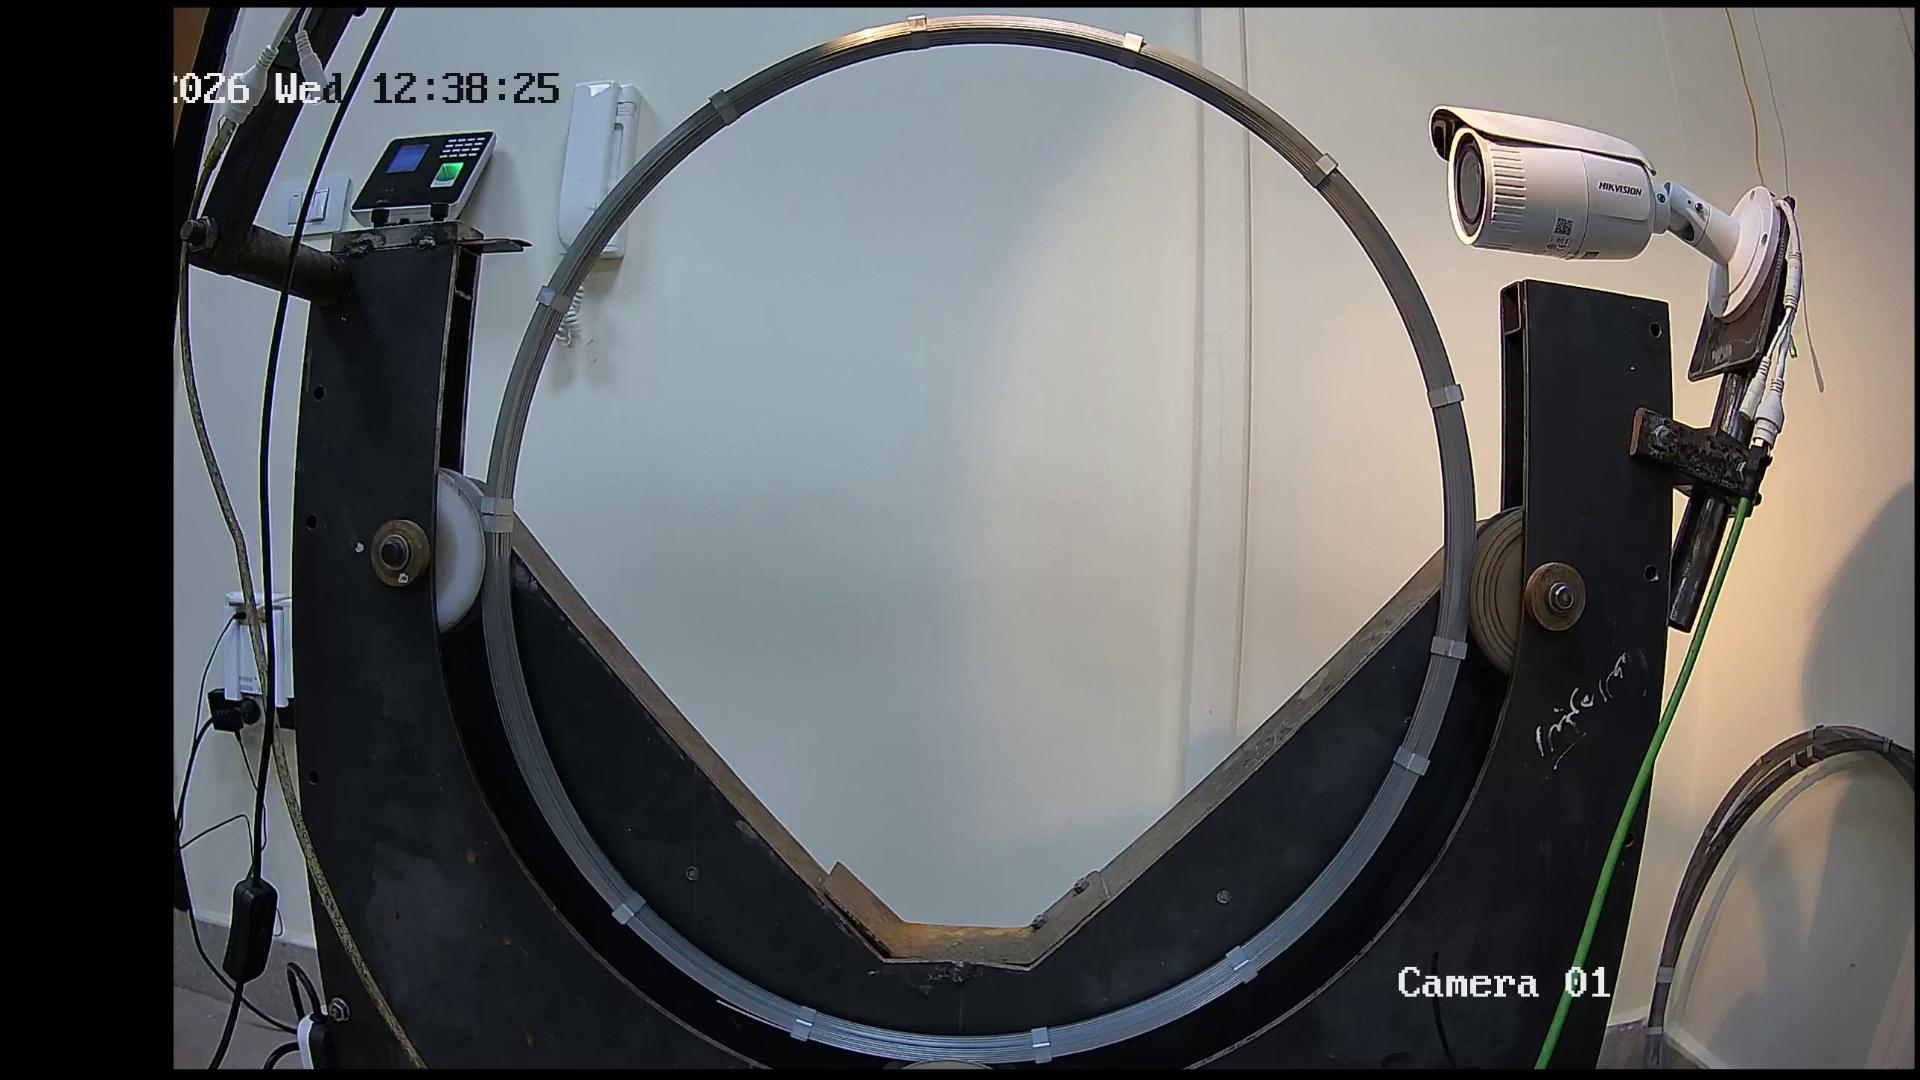

In [25]:
from IPython.display import Image as IPyImage

IPyImage(filename=f'./clamps-task-1/train/images/frame_001_jpg.rf.71a1b962be9b10130774044109eabac8.jpg', width=600)

In [28]:
import os
HOME = os.getcwd()

!pip install -q ultralytics

%cd {HOME}
!yolo task=detect mode=train model=yolo11m.pt data={dataset.location}/data.yaml epochs=100 imgsz=640 plots=True

/content
100% 38.8M/38.8M [00:00<00:00, 147MB/s]
New https://pypi.org/project/ultralytics/8.4.50 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: task=detect, mode=train, model=yolo11m.pt, data=/content/clamps-task-1/data.yaml, epochs=100, time=None, patience=100, batch=16, imgsz=640, save=True, save_period=-1, cache=False, device=None, workers=8, project=None, name=train3, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None

In [29]:
!yolo task=detect mode=predict model=runs/detect/train3/weights/best.pt source="/content/Task.mp4" save=True

Ultralytics 8.3.40 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
YOLO11m summary (fused): 303 layers, 20,030,803 parameters, 0 gradients, 67.6 GFLOPs

video 1/1 (frame 1/1251) /content/Task.mp4: 384x640 13 clamps, 67.9ms
video 1/1 (frame 2/1251) /content/Task.mp4: 384x640 13 clamps, 23.9ms
video 1/1 (frame 3/1251) /content/Task.mp4: 384x640 13 clamps, 23.9ms
video 1/1 (frame 4/1251) /content/Task.mp4: 384x640 13 clamps, 23.9ms
video 1/1 (frame 5/1251) /content/Task.mp4: 384x640 13 clamps, 24.0ms
video 1/1 (frame 6/1251) /content/Task.mp4: 384x640 14 clamps, 23.9ms
video 1/1 (frame 7/1251) /content/Task.mp4: 384x640 13 clamps, 23.9ms
video 1/1 (frame 8/1251) /content/Task.mp4: 384x640 13 clamps, 23.9ms
video 1/1 (frame 9/1251) /content/Task.mp4: 384x640 13 clamps, 23.9ms
video 1/1 (frame 10/1251) /content/Task.mp4: 384x640 13 clamps, 23.9ms
video 1/1 (frame 11/1251) /content/Task.mp4: 384x640 13 clamps, 23.9ms
video 1/1 (frame 12/1251) /content/Task.mp4: 384x640 13 cla

In [33]:
import cv2
from ultralytics import YOLO

model = YOLO("runs/detect/train3/weights/best.pt")

video_path = "/content/Task.mp4"
cap = cv2.VideoCapture(video_path)

width  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
height = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
fps    = int(cap.get(cv2.CAP_PROP_FPS))

output_path = "/content/output_with_count.avi"
out = cv2.VideoWriter(output_path, cv2.VideoWriter_fourcc(*'XVID'), fps, (width, height))
while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break
    results = model(frame, conf=0.25, verbose=False)
    annotated_frame = results[0].plot()
    clamp_count = len(results[0].boxes)
    text = f"Clamps Count: {clamp_count}"
    cv2.putText(annotated_frame, text, (50, 50),
                cv2.FONT_HERSHEY_SIMPLEX, 1.5, (0, 0, 255), 3, cv2.LINE_AA)
    out.write(annotated_frame)

cap.release()
out.release()
print(f"Done! Video saved as {output_path}")

Done! Video saved as /content/output_with_count.mp4
